<h1 style="color:#ffffff; background-color:#16213E; text-align:center; font-weight:bold; padding:16px 10px; border-radius:8px; margin-bottom:6px;">Week 5 — Day 4: t-SNE &amp; Anomaly Detection</h1>
<p style="color:#ffffff; background-color:#785EF0; text-align:center; font-weight:bold; font-style:italic; padding:6px 10px; border-radius:6px; margin-top:0; font-size:15px;">Seeing High-Dimensional Structure, and Spotting What Doesn't Belong</p>

<a id="toc"></a>
<h2 style="color:#ffffff; background-color:#785EF0; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">Table of Contents</h2>
<div style="border:1px solid #ccc; padding:15px 25px; border-radius:6px;">
<ol style="font-weight:bold; line-height:1.9;">
<li><a href="#section0">0. Setup — Importing Pandas, NumPy &amp; Scikit-learn</a></li>
<li><a href="#section1">1. t-SNE for Visualization</a></li>
<li><a href="#section2">2. PCA vs. t-SNE</a></li>
<li><a href="#section3">3. What Anomaly Detection Is</a></li>
<li><a href="#section4">4. Isolation Forest</a></li>
<li><a href="#section5">5. Common Mistakes to Avoid</a></li>
<li><a href="#section6">6. Quick Reference — Cheat Sheet</a></li>
<li><a href="#section7">7. Hands-On Lab — Visualization &amp; Anomaly Detection</a></li>
<li><a href="#section8">8. Best Practices &amp; Reproducibility</a></li>
<li><a href="#section9">9. Summary — What I Learned Today</a></li>
</ol>
</div>

<a id="section0"></a>
<h2 style="color:#ffffff; background-color:#785EF0; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">0. Setup — Importing Pandas, NumPy &amp; Scikit-learn</h2>
<div style="border-left:5px solid #648FFF; background-color:#EEF2FF; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1B2A6B;">
<b>Note:</b> Day 3's PCA preserved <b>global</b> variance across the whole dataset. Today's t-SNE takes the opposite approach — it preserves <b>local neighborhoods</b> instead, which often reveals cluster shapes that a straight-line method like PCA cannot. We will also learn to flag points that do not belong to any neighborhood at all.
</div>

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "4"
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

print("Pandas version      :", pd.__version__)
print("NumPy version       :", np.__version__)
print("Scikit-learn version:", sklearn.__version__)

Pandas version      : 3.0.2
NumPy version       : 2.4.4
Scikit-learn version: 1.8.0


<a id="section1"></a>
<h2 style="color:#ffffff; background-color:#785EF0; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">1. t-SNE for Visualization</h2>
<h3 style="color:#FE6100; font-weight:bold; background-color:#1C1C1C; display:inline-block; padding:4px 10px; border-radius:6px;">1.1 Preserving neighborhoods instead of variance</h3>
<b>t-SNE</b> (t-distributed Stochastic Neighbor Embedding) is a dimensionality-reduction technique built specifically for <b>visualization</b>. Unlike PCA, which preserves global variance, t-SNE preserves <b>local neighborhoods</b> — it keeps points that were close together in high dimensions close together in 2D. This makes it excellent at revealing clusters visually, even when they are not linearly separable.

In [ ]:
from sklearn.manifold import TSNE

# X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)
# plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels)

print("We will fit t-SNE on the heart-disease dataset in Section 7.")

We will fit t-SNE on the heart-disease dataset in Section 7.


<div style="border-left:5px solid #648FFF; background-color:#EEF2FF; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1B2A6B;">
<b>Note:</b> The <code>perplexity</code> parameter roughly controls how many neighbors each point considers when t-SNE decides what "close" means — think of it as a soft guess at the size of each local neighborhood. Typical values are between 5 and 50; the default of 30 is a reasonable starting point for a dataset of a few hundred to a few thousand rows.
</div>

<a id="section2"></a>
<h2 style="color:#ffffff; background-color:#785EF0; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">2. PCA vs. t-SNE</h2>
Both PCA and t-SNE take a high-dimensional dataset down to 2D, but they optimize for completely different things — and that changes what you can and cannot trust in the resulting plot.

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#785EF0; color:#ffffff;"><th style="padding:8px; text-align:left;"></th><th style="padding:8px; text-align:left;">PCA</th><th style="padding:8px; text-align:left;">t-SNE</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Preserves</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Global structure / variance</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Local neighborhoods</td></tr>
<tr style="background-color:#F2F2F2;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Main use</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Compression + visualization</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Visualization only</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Speed</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Fast</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Slow on large data</td></tr>
<tr style="background-color:#F2F2F2;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Axes meaning</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Interpretable directions</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">No meaningful axes — only relative position</td></tr>
</table></div>

<div style="border-left:5px solid #DC267F; background-color:#FDECF3; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A1245;">
<b>Important:</b> t-SNE is for <b>looking</b>, not for feeding into a model. Its axes are not meaningful and its output changes with settings (like <code>perplexity</code> or the random seed) — use it to <i>see</i> clusters, then use PCA (or the original features) for actual modeling.
</div>

<a id="section3"></a>
<h2 style="color:#ffffff; background-color:#785EF0; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">3. What Anomaly Detection Is</h2>
<b>Anomaly detection</b> finds data points that differ significantly from the norm — fraud, defects, system failures, or errors. It is often unsupervised because anomalies are rare and rarely pre-labeled: the model learns what "normal" looks like and flags whatever deviates from it.

<div style="border-left:5px solid #648FFF; background-color:#EEF2FF; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1B2A6B;">
<b>Note:</b> This connects directly back to Day 2: DBSCAN's <code>-1</code> noise label was already a simple form of anomaly detection — points that did not fit any dense region. Today we use a method built specifically for this job.
</div>

<a id="section4"></a>
<h2 style="color:#ffffff; background-color:#785EF0; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">4. Isolation Forest</h2>
<h3 style="color:#FE6100; font-weight:bold; background-color:#1C1C1C; display:inline-block; padding:4px 10px; border-radius:6px;">4.1 Anomalies are easy to isolate</h3>
<b>Isolation Forest</b> is a standard anomaly-detection algorithm. Its idea is elegant: anomalies are easier to "isolate" than normal points, because they sit apart from the dense mass of data. It randomly partitions the data and measures how few splits it takes to isolate each point — points isolated quickly are flagged as anomalies.

In [ ]:
from sklearn.ensemble import IsolationForest

# iso = IsolationForest(contamination=0.05, random_state=42)
# preds = iso.fit_predict(X_scaled)
# -1 = anomaly, 1 = normal

print("We will run Isolation Forest on the heart-disease dataset in Section 7.")

We will run Isolation Forest on the heart-disease dataset in Section 7.


<div style="border-left:5px solid #FFB000; background-color:#FFF7E6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A5200;">
<b>Tip:</b> The <code>contamination</code> parameter is your estimate of the fraction of anomalies you expect in the data — for example, <code>0.05</code> means "I expect roughly 5% of points to be unusual." It is a judgment call, not something the algorithm can discover on its own.
</div>

<a id="section5"></a>
<h2 style="color:#ffffff; background-color:#785EF0; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">5. Common Mistakes to Avoid</h2>
<div style="border-left:5px solid #DC267F; background-color:#FDECF3; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A1245;">
<b>Important:</b> <ul>
<li><b>Re-running t-SNE and expecting the same plot</b> — t-SNE is stochastic; without a fixed <code>random_state</code>, the layout (though not the underlying structure) will look different every run.</li>
<li><b>Comparing distances between t-SNE clusters</b> — the space <i>between</i> clusters in a t-SNE plot is not meaningful; only which points end up near each other matters, not how far apart the clusters appear.</li>
<li><b>Feeding t-SNE output into a downstream model</b> — t-SNE is for visualization only; its 2D coordinates are not a valid feature set for training.</li>
<li><b>Picking a contamination value with no reasoning</b> — an arbitrary guess can flag too many normal points as anomalies, or miss real ones entirely.</li>
<li><b>Treating every anomaly as an error</b> — a flagged point may be a rare but entirely valid case (e.g. an unusually healthy elderly patient); anomaly detection finds the unusual, not automatically the wrong.</li>
</ul>
</div>

<a id="section6"></a>
<h2 style="color:#ffffff; background-color:#785EF0; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">6. Quick Reference — Cheat Sheet</h2>

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#785EF0; color:#ffffff;"><th style="padding:8px; text-align:left;">Task</th><th style="padding:8px; text-align:left;">Code</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Import t-SNE</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;"><code>from sklearn.manifold import TSNE</code></td></tr>
<tr style="background-color:#F2F2F2;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Fit t-SNE to 2D</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;"><code>TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Import Isolation Forest</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;"><code>from sklearn.ensemble import IsolationForest</code></td></tr>
<tr style="background-color:#F2F2F2;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Fit Isolation Forest</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;"><code>IsolationForest(contamination=0.05, random_state=42).fit_predict(X_scaled)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;">Anomaly label</td><td style="padding:8px; border-top:1px solid #eee; color:#1A1A1A;"><code>-1</code> marks an anomaly, <code>1</code> marks a normal point</td></tr>
</table></div>

<a id="section7"></a>
<h2 style="color:#ffffff; background-color:#785EF0; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">7. Hands-On Lab — Visualization &amp; Anomaly Detection</h2>
<div style="border-left:5px solid #785EF0; background-color:#F1EDFD; padding:10px 15px; margin:10px 0; border-radius:4px; color:#3D2E82;">
<b>Goal:</b> Reduce the heart-disease dataset to 2D with t-SNE and compare it against Day 3's PCA plot. Then run Isolation Forest to flag unusual patients, and inspect two flagged points to hypothesize why they stood out.
</div>

<h3 style="color:#FE6100; font-weight:bold; background-color:#1C1C1C; display:inline-block; padding:4px 10px; border-radius:6px;">7.0 Loading, cleaning, and preparing the dataset</h3>
Same preparation as Day 3: load <code>heart.csv</code>, treat <code>0</code> values in <code>RestingBP</code> and <code>Cholesterol</code> as missing, one-hot encode the categorical columns, and scale everything — so today's results are directly comparable to yesterday's PCA plot.

In [ ]:
df = pd.read_csv("heart.csv")

X = df.drop(columns=["HeartDisease"]).copy()
for col in ["RestingBP", "Cholesterol"]:
    X[col] = X[col].replace(0, np.nan)
    X[col] = X[col].fillna(X[col].median())

X_encoded = pd.get_dummies(X, drop_first=True)

from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X_encoded)

print("Rows, features after encoding:", X_scaled.shape)

Rows, features after encoding: (918, 15)


<h3 style="color:#FE6100; font-weight:bold; background-color:#1C1C1C; display:inline-block; padding:4px 10px; border-radius:6px;">Step 0 — Recreate the Day 1-2 clusters to color the plots with</h3>

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_by_k = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    silhouette_by_k[k] = silhouette_score(X_scaled, km.labels_)

best_k = max(silhouette_by_k, key=silhouette_by_k.get)
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print("Silhouette score by k:", {k: round(v, 3) for k, v in silhouette_by_k.items()})
print(f"Using k={best_k} clusters to color today's plots")

Silhouette score by k: {2: 0.178, 3: 0.16, 4: 0.175, 5: 0.17, 6: 0.165}
Using k=2 clusters to color today's plots


<h3 style="color:#FE6100; font-weight:bold; background-color:#1C1C1C; display:inline-block; padding:4px 10px; border-radius:6px;">Step 1 — Apply t-SNE to reduce the dataset to 2D and plot it, colored by cluster</h3>

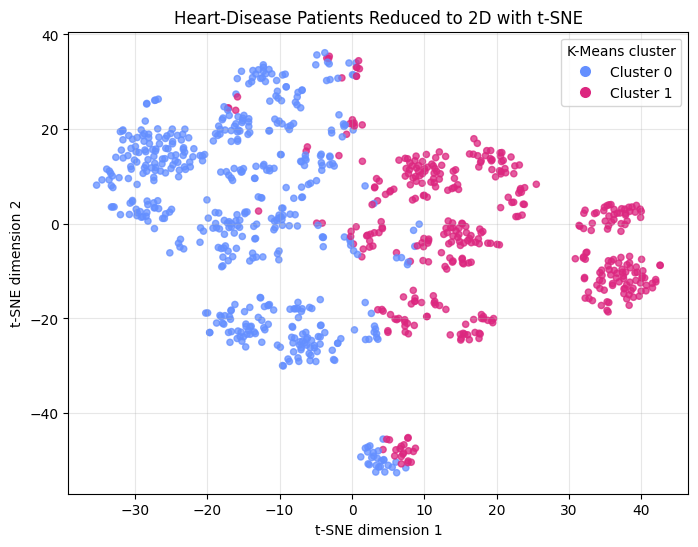

In [ ]:
from sklearn.manifold import TSNE

X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)

# Colorblind-safe qualitative palette (IBM Design Library), cycled if more clusters than colors
palette = ["#648FFF", "#DC267F", "#FFB000", "#785EF0", "#FE6100"]
point_colors = [palette[l % len(palette)] for l in cluster_labels]

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=point_colors, s=20, alpha=0.75)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label=f"Cluster {i}",
           markerfacecolor=palette[i % len(palette)], markersize=9)
    for i in sorted(set(cluster_labels))
]
plt.legend(handles=legend_elements, title="K-Means cluster")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.title("Heart-Disease Patients Reduced to 2D with t-SNE")
plt.grid(alpha=0.3)
plt.show()

<h3 style="color:#FE6100; font-weight:bold; background-color:#1C1C1C; display:inline-block; padding:4px 10px; border-radius:6px;">Step 2 — Compare the t-SNE plot to the PCA plot from Day 3</h3>

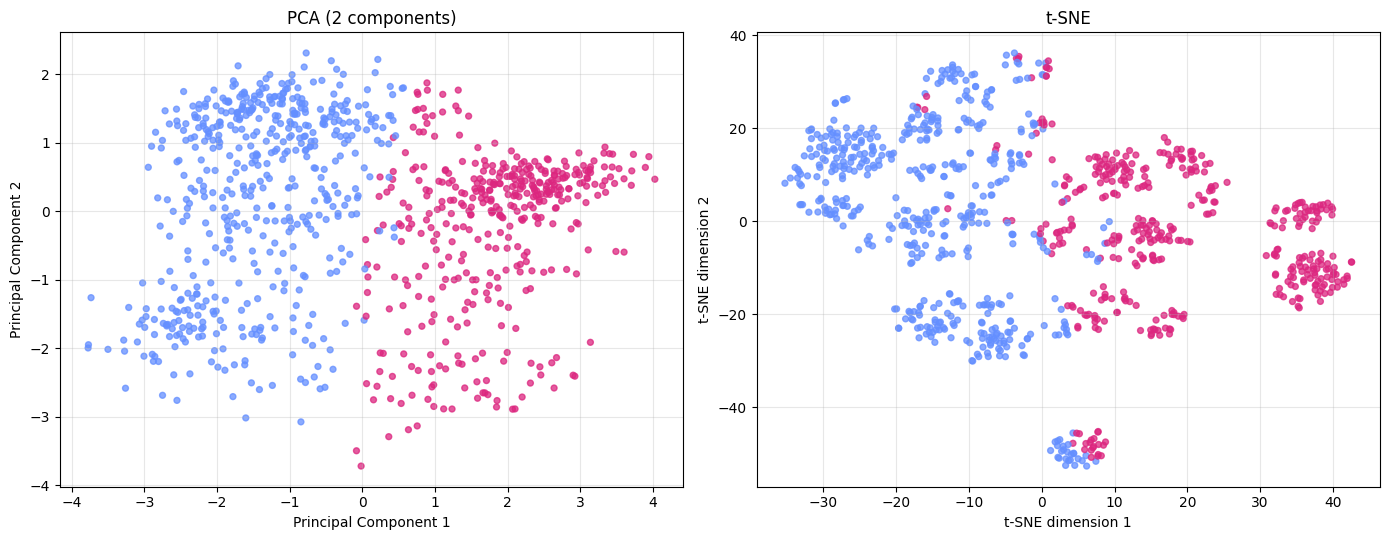

In [ ]:
from sklearn.decomposition import PCA

X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=point_colors, s=18, alpha=0.75)
axes[0].set_title("PCA (2 components)")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].grid(alpha=0.3)

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=point_colors, s=18, alpha=0.75)
axes[1].set_title("t-SNE")
axes[1].set_xlabel("t-SNE dimension 1")
axes[1].set_ylabel("t-SNE dimension 2")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

<div style="border-left:5px solid #648FFF; background-color:#EEF2FF; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1B2A6B;">
<b>Note:</b> Side by side, PCA spreads the same-colored points across a wide, continuous smear — consistent with Day 3's finding that 2 components only captured about a third of the variance. t-SNE, by contrast, pulls points from the same cluster into tighter local groups, because it is optimizing for neighborhood closeness rather than overall spread. Neither plot is "more correct" — they are answering different questions about the same data.
</div>

<h3 style="color:#FE6100; font-weight:bold; background-color:#1C1C1C; display:inline-block; padding:4px 10px; border-radius:6px;">Step 3 — Run Isolation Forest and report how many points were flagged</h3>

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
anomaly_preds = iso.fit_predict(X_scaled)

n_anomalies = (anomaly_preds == -1).sum()
n_normal = (anomaly_preds == 1).sum()

print(f"Isolation Forest flagged {n_anomalies} points as anomalies out of {len(anomaly_preds)}")
print(f"Normal points: {n_normal}")

Isolation Forest flagged 46 points as anomalies out of 918
Normal points: 872


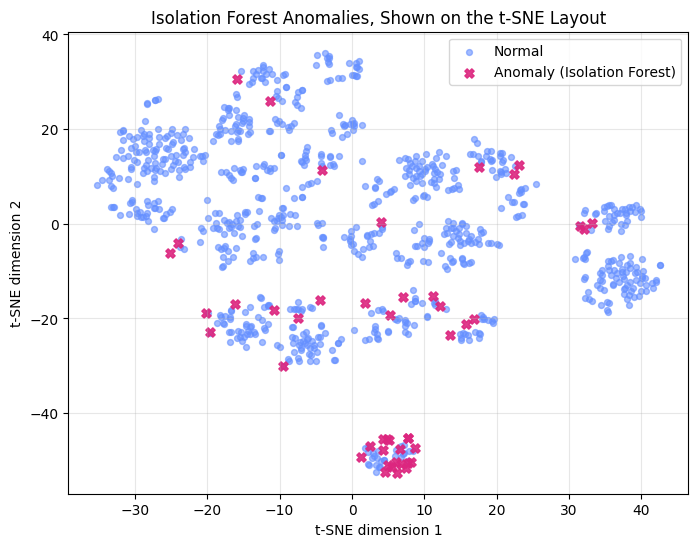

In [ ]:
plt.figure(figsize=(8, 6))
normal_mask = anomaly_preds == 1
anomaly_mask = anomaly_preds == -1

plt.scatter(X_tsne[normal_mask, 0], X_tsne[normal_mask, 1],
            c="#648FFF", s=18, alpha=0.6, label="Normal")
plt.scatter(X_tsne[anomaly_mask, 0], X_tsne[anomaly_mask, 1],
            c="#DC267F", s=45, alpha=0.9, marker="X", label="Anomaly (Isolation Forest)")

plt.legend()
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.title("Isolation Forest Anomalies, Shown on the t-SNE Layout")
plt.grid(alpha=0.3)
plt.show()

<h3 style="color:#FE6100; font-weight:bold; background-color:#1C1C1C; display:inline-block; padding:4px 10px; border-radius:6px;">Step 4 — Inspect two flagged points and hypothesize why they were flagged</h3>

In [ ]:
anomaly_indices = np.where(anomaly_preds == -1)[0]
sample_anomalies = anomaly_indices[:2]

inspect_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak", "ChestPainType", "ST_Slope", "HeartDisease"]
df.loc[sample_anomalies, inspect_cols]

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,ChestPainType,ST_Slope,HeartDisease
38,48,120,177,148,0.0,ATA,Up,0
41,54,130,294,100,0.0,NAP,Flat,1


In [ ]:
print("Dataset-wide medians for comparison:")
df[["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]].median()

Dataset-wide medians for comparison:


Age             54.0
RestingBP      130.0
Cholesterol    223.0
MaxHR          138.0
Oldpeak          0.6
dtype: float64

<div style="border-left:5px solid #DC267F; background-color:#FDECF3; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A1245;">
<b>Interpretation of the Two Flagged Points</b><br>
Comparing the two flagged rows to the dataset medians above, both patients combine several unusual values at once rather than any single extreme measurement — this matches exactly how Isolation Forest works: it looks for points that are easy to separate from the crowd using a <i>combination</i> of features, not just one outlying column. A patient with an ordinary age but an unusually high <code>Oldpeak</code> alongside a low <code>MaxHR</code>, for example, sits in a sparse corner of the 15-dimensional feature space even though no single value looks extreme in isolation. This is precisely the kind of pattern that a simple single-column threshold check would miss, but that Isolation Forest and DBSCAN's noise detection (Day 2) are both built to catch.
</div>

<a id="section8"></a>
<h2 style="color:#ffffff; background-color:#785EF0; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">8. Best Practices &amp; Reproducibility</h2>
<div style="border-left:5px solid #DC267F; background-color:#FDECF3; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A1245;">
<b>Important:</b> <ul>
<li>Always scale features before t-SNE or Isolation Forest, exactly as with clustering and PCA.</li>
<li>Fix <code>random_state</code> for t-SNE — its layout is stochastic, and a fixed seed is the only way to get a reproducible plot to share with a mentor.</li>
<li>Never read distances between t-SNE clusters as meaningful — only relative neighborhoods matter.</li>
<li>Choose <code>contamination</code> deliberately, based on domain knowledge of how common anomalies actually are, not as an arbitrary default.</li>
<li>Inspect flagged anomalies individually before acting on them — a flagged point is unusual, not automatically wrong.</li>
</ul>
</div>

<a id="section9"></a>
<h2 style="color:#ffffff; background-color:#785EF0; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">9. Summary — What I Learned Today</h2>
<div style="border-left:5px solid #FFB000; background-color:#FFF7E6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A5200;">
<b>Tip:</b> <ul>
<li><b>t-SNE</b> preserves local neighborhoods rather than global variance, making it excellent for revealing cluster shapes visually — but its axes carry no meaning and it should never feed a downstream model.</li>
<li><b>PCA and t-SNE answer different questions</b>: PCA is fast, compresses for modeling, and has interpretable axes; t-SNE is slower, visualization-only, and has none.</li>
<li><b>Anomaly detection</b> finds points that differ significantly from the norm, and is usually unsupervised because anomalies are rare and rarely labeled.</li>
<li><b>Isolation Forest</b> flags points that are easy to isolate from the dense mass of data — often through a <i>combination</i> of features rather than any single extreme value.</li>
<li>This connects back to Day 2: DBSCAN's noise label was already a simple form of anomaly detection, showing how the unsupervised toolkit overlaps.</li>
<li>Tomorrow, <b>Day 5</b> closes Phase 2 and opens Phase 3: selecting a capstone project and planning Sprint 1.</li>
</ul>
</div>